# Экспериментальная ветка синтетических данных

> **Этот notebook документирует экспериментальную ветку синтетических данных. Синтетические данные не использовались для обучения финальных весов PP-LCNet.**

Полный generator v1.1 применялся только к локально обучаемым моделям B2/B3/B4 и в отдельном диагностическом stress-test. По умолчанию здесь создаются лишь три небольшие детерминированные пары в памяти; набор из 16 000 изображений не генерируется.

## Зачем нужна синтетика и как строится точная пара

Генератор позволял контролировать текст, фон, освещение и деградации, а также получать однозначную метку ориентации.

```text
отрисовка → геометрия → поверхность и освещение → blur → уменьшение
→ шум и JPEG → готовый upright-растр → точный ROTATE_180
```

Поворот выполняется после всех случайных преобразований. Поэтому члены пары содержат одинаковые пиксели и отличаются только ориентацией.

## Импорты и переносимый кириллический шрифт

Поиск проверяет стандартные каталоги Windows, Linux и macOS, затем известные системные семейства. Перед использованием проверяются кириллические глифы. Шрифты в репозиторий не включены.

In [ ]:
from __future__ import annotations

import hashlib
import io
import os
import platform
import random
from pathlib import Path

from PIL import Image, ImageDraw, ImageEnhance, ImageFilter, ImageFont

SEED = 20260927
print(f"SEED детерминированной демонстрации: {SEED}")

def _glyph_signature(font: ImageFont.FreeTypeFont, symbol: str) -> tuple[tuple[int, int], bytes]:
    mask = font.getmask(symbol, mode="L")
    return mask.size, bytes(mask)


def find_cyrillic_font(size: int) -> tuple[ImageFont.FreeTypeFont, str]:
    """Найти системный TrueType-шрифт и подтвердить кириллические глифы."""
    candidates: list[Path | str] = []
    system = platform.system()
    if system == "Windows":
        fonts = Path(os.environ.get("WINDIR", r"C:\Windows")) / "Fonts"
        candidates += [fonts / "arialbd.ttf", fonts / "segoeuib.ttf", fonts / "calibrib.ttf"]
    elif system == "Darwin":
        candidates += [
            Path("/System/Library/Fonts/Supplemental/Arial Bold.ttf"),
            Path("/System/Library/Fonts/Supplemental/Arial Unicode.ttf"),
            Path("/Library/Fonts/Arial Unicode.ttf"),
        ]
    else:
        candidates += [
            Path("/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf"),
            Path("/usr/share/fonts/truetype/liberation2/LiberationSans-Bold.ttf"),
            Path("/usr/share/fonts/truetype/freefont/FreeSansBold.ttf"),
        ]
    candidates += ["DejaVuSans-Bold.ttf", "Arial Bold.ttf", "Arial.ttf", "LiberationSans-Bold.ttf"]

    checked = []
    for candidate in candidates:
        text = str(candidate)
        if isinstance(candidate, Path) and not candidate.is_file():
            continue
        checked.append(text)
        try:
            font = ImageFont.truetype(text, size)
        except (OSError, ValueError):
            continue
        replacement = _glyph_signature(font, "�")
        signatures = [_glyph_signature(font, symbol) for symbol in "ЖЯБ"]
        if all(sig[0] != (0, 0) and any(sig[1]) and sig != replacement for sig in signatures):
            return font, text
    raise FileNotFoundError(
        "Не найден системный TrueType-шрифт с кириллицей. Установите DejaVu Sans, "
        "Arial, Liberation Sans или FreeSans. Проверены: " + ", ".join(checked)
    )

## Детерминированная демонстрация realistic v1.1

Пример включает текстурированный фон, тень, обводку, небольшой affine-сдвиг, blur, уменьшение и JPEG.

Источник кириллического шрифта: /usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf
Создано пар в памяти: 3
SHA256 первого upright: 4f7c274b2b094fb441d3aa1dd785d3451ec05191b134d6e4373cdc145a346235
Файлы набора данных не записывались.
Контактный лист создан; текущая среда выполнения не поддерживает встроенный display.


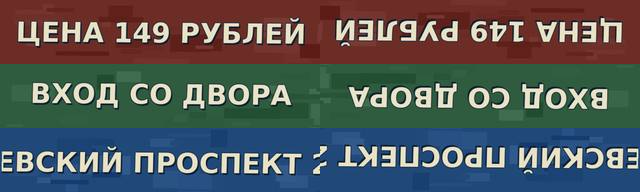

In [2]:
def render_smoke_upright(seed: int) -> Image.Image:
    rng = random.Random(seed)
    width, height = 960, 192
    backgrounds = [(28, 72, 126), (112, 42, 36), (44, 92, 61)]
    texts = ["НЕВСКИЙ ПРОСПЕКТ 24", "ЦЕНА 149 РУБЛЕЙ", "ВХОД СО ДВОРА"]
    background = backgrounds[seed % len(backgrounds)]
    foreground = (246, 239, 208)
    image = Image.new("RGB", (width, height), background)
    draw = ImageDraw.Draw(image)
    for _ in range(24):
        shade = rng.randint(-18, 18)
        color = tuple(max(0, min(255, channel + shade)) for channel in background)
        x0, y0 = rng.randrange(width), rng.randrange(height)
        draw.rectangle((x0, y0, min(width, x0+rng.randint(25,180)), min(height, y0+rng.randint(8,55))), fill=color)

    text = texts[seed % len(texts)]
    font, source = find_cyrillic_font(82)
    box = draw.textbbox((0, 0), text, font=font, stroke_width=2)
    x = (width-(box[2]-box[0]))//2
    y = (height-(box[3]-box[1]))//2-box[1]
    draw.text((x+4,y+5), text, font=font, fill=(5,25,45))
    draw.text((x,y), text, font=font, fill=foreground, stroke_width=2, stroke_fill=(12,32,55))
    image = image.transform(image.size, Image.Transform.AFFINE, (1,0.025,-8,-0.008,1,4), resample=Image.Resampling.BICUBIC, fillcolor=background)
    image = ImageEnhance.Contrast(image).enhance(0.92).filter(ImageFilter.GaussianBlur(0.65))
    image = image.resize((320,64), Image.Resampling.LANCZOS)
    buffer=io.BytesIO(); image.save(buffer,format="JPEG",quality=72,subsampling=2); buffer.seek(0)
    result=Image.open(buffer).convert("RGB"); result.info["font_source"]=source
    return result

pairs=[]
for offset in range(3):
    upright=render_smoke_upright(SEED+offset)
    rotated=upright.transpose(Image.Transpose.ROTATE_180)
    assert rotated.transpose(Image.Transpose.ROTATE_180).tobytes()==upright.tobytes()
    pairs.append((upright,rotated))

contact_sheet = Image.new("RGB", (640, 64 * len(pairs)), "white")
for row, (upright, rotated) in enumerate(pairs):
    contact_sheet.paste(upright, (0, row * 64))
    contact_sheet.paste(rotated, (320, row * 64))

print("Источник кириллического шрифта:", pairs[0][0].info.get("font_source"))
print("Создано пар в памяти:", len(pairs))
print("SHA256 первого upright:", hashlib.sha256(pairs[0][0].tobytes()).hexdigest())
print("Файлы набора данных не записывались.")
# В Jupyter последняя строка показывает три пары: upright слева, 180° справа.
try:
    display(contact_sheet)  # Jupyter показывает три пары: upright слева, 180° справа.
except NameError:
    print("Контактный лист создан; текущая среда выполнения не поддерживает встроенный display.")


## Результаты исследовательской ветки

| Данные B4 | Brier на TextOCR dev |
|---|---:|
| realistic v1.1, 0% TextOCR | 0.251392 |
| simple synthetic | 0.280964 |
| realistic + 5% TextOCR, первый seed | **0.248635** |
| realistic + 10% TextOCR | 0.250130 |
| realistic + 20% TextOCR | 0.250549 |
| realistic + 5% TextOCR, второй seed | 0.250277 |

Realistic v1.1 был лучше simple synthetic, но абсолютное качество B4 оставалось слабым. Доля 5% была рабочей точечной оценкой и не доказанным оптимумом. Эта ветка не обучала и никак не изменяла финальную PP-LCNet.

## Разрыв с реальным доменом

| Статистика | Синтетика | Competition test |
|---|---:|---:|
| энтропия | 4.782 | 6.182 |
| доля почти серых пикселей | 0.555 | 0.405 |
| Laplacian при h=32 | 2591.7 | 1752.8 |

Геометрия была согласована лучше внешнего вида. Поэтому synthetic validation не считалась доказательством качества на реальном домене, а TextOCR использовался как real-general validation.

In [3]:
RESULTS = {
    "generator_version": "1.1",
    "full_experiment_pairs": 8000,
    "default_demo_pairs": len(pairs),
    "final_pp_lcnet_trained_by_this_branch": False,
    "realistic_brier": 0.251392,
    "simple_brier": 0.280964,
    "working_real_general_share_percent": 5,
    "working_choice_is_proven_optimum": False,
}
assert RESULTS["default_demo_pairs"] == 3
assert RESULTS["final_pp_lcnet_trained_by_this_branch"] is False
assert RESULTS["realistic_brier"] < RESULTS["simple_brier"]
print("Проверки демонстрации: успешно.")

Проверки демонстрации: успешно.
